In [3]:
# If needed, install the libraries first:
%pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    mutual_info_classif
)
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.8 MB 6.6 MB/s eta 0:00:02
   ------------ --------------------------- 3.1/9.8 MB 7.7 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.8 MB 8.0 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.8 MB 8.9 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.8 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 9.0 MB/s  0:00:01
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ------ --------------------------------- 2.1/12.7 MB 10.2 MB/s eta 0:00:02
   ----------- ---------------------------- 3.7/12.7 MB 8.9 MB/s eta 0:00:02
   ------------------ --------------------- 6.0/12.7 MB 10.2 MB/s eta 0:00:01
   -------------------------- ------------- 8.4/12.7 MB 10.0 MB/s eta 0:00:01
   --------------------------------- ------ 10.5/12.7 MB 10.1 MB/s eta 0:00:01
   ---------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Load the public dataset

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    url,
    names=columns,
    na_values="?",
    skipinitialspace=True
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (32561, 15)


Display the first records

In [5]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Check dataset information

In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB
None


In [7]:
print(df.dtypes)

age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
dtype: object


Check the number of rows and columns

In [8]:
rows, columns_count = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns_count)

Number of rows: 32561
Number of columns: 15


Check missing values

In [9]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


To calculate percentages:

In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

print(missing_summary)

                Missing Count  Missing Percentage
age                         0            0.000000
workclass                1836            5.638647
fnlwgt                      0            0.000000
education                   0            0.000000
education_num               0            0.000000
marital_status              0            0.000000
occupation               1843            5.660146
relationship                0            0.000000
race                        0            0.000000
sex                         0            0.000000
capital_gain                0            0.000000
capital_loss                0            0.000000
hours_per_week              0            0.000000
native_country            583            1.790486
income                      0            0.000000


Check duplicate records

In [11]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 24


Remove duplicates:

In [12]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (32537, 15)


Descriptive statistics

In [13]:
print(df.describe())

                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  32537.000000  3.253700e+04   32537.000000  32537.000000  32537.000000   
mean      38.585549  1.897808e+05      10.081815   1078.443741     87.368227   
std       13.637984  1.055565e+05       2.571633   7387.957424    403.101833   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.369930e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours_per_week  
count    32537.000000  
mean        40.440329  
std         12.346889  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


In [14]:
print(df.describe(include="object"))

       workclass education      marital_status      occupation relationship  \
count      30701     32537               32537           30694        32537   
unique         8        16                   7              14            6   
top      Private   HS-grad  Married-civ-spouse  Prof-specialty      Husband   
freq       22673     10494               14970            4136        13187   

         race    sex native_country income  
count   32537  32537          31955  32537  
unique      5      2             41      2  
top     White   Male  United-States  <=50K  
freq    27795  21775          29153  24698  


Check unique categorical values

In [15]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 workclass
<StringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',                nan,
     'Self-emp-inc',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

 education
<StringArray>
[   'Bachelors',      'HS-grad',         '11th',      'Masters',
          '9th', 'Some-college',   'Assoc-acdm',    'Assoc-voc',
      '7th-8th',    'Doctorate',  'Prof-school',      '5th-6th',
         '10th',      '1st-4th',    'Preschool',         '12th']
Length: 16, dtype: str

 marital_status
<StringArray>
[        'Never-married',    'Married-civ-spouse',              'Divorced',
 'Married-spouse-absent',             'Separated',     'Married-AF-spouse',
               'Widowed']
Length: 7, dtype: str

 occupation
<StringArray>
[     'Adm-clerical',   'Exec-managerial', 'Handlers-cleaners',
    'Prof-specialty',     'Other-service',             'Sales',
      'Craft-repair',  'Transport-moving',   'Farming-fishing',
 'Machine-

Check numerical columns

In [16]:
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical columns:")
print(list(numeric_columns))

Numerical columns:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


Visualize missing values

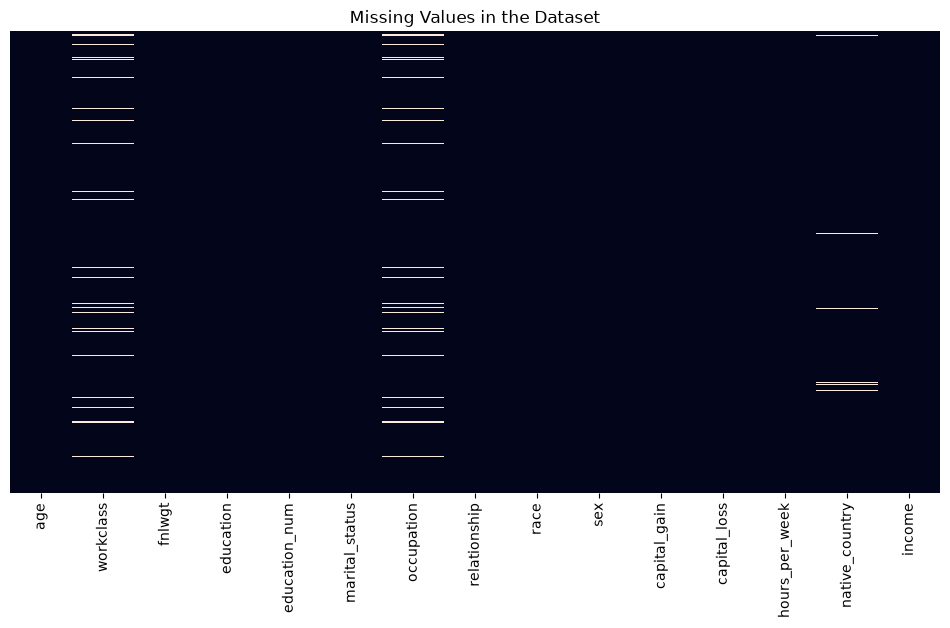

In [17]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values in the Dataset")
plt.show()

Analyze the target variable,Visualize it:

income
<=50K    24698
>50K      7839
Name: count, dtype: int64


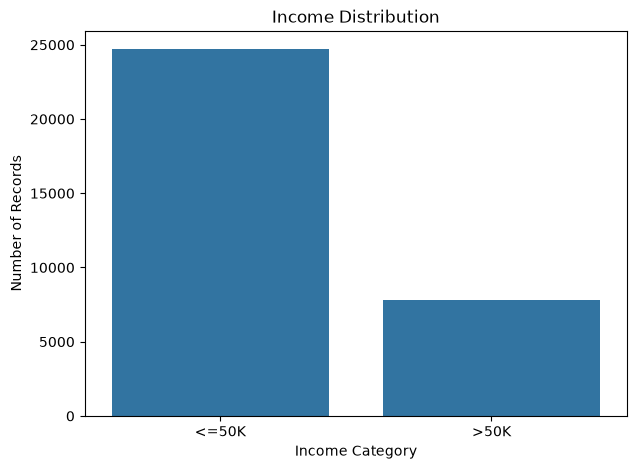

In [20]:
print(df["income"].value_counts())



plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="income"
)

plt.title("Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Records")

plt.show()

Analyze numerical distributions

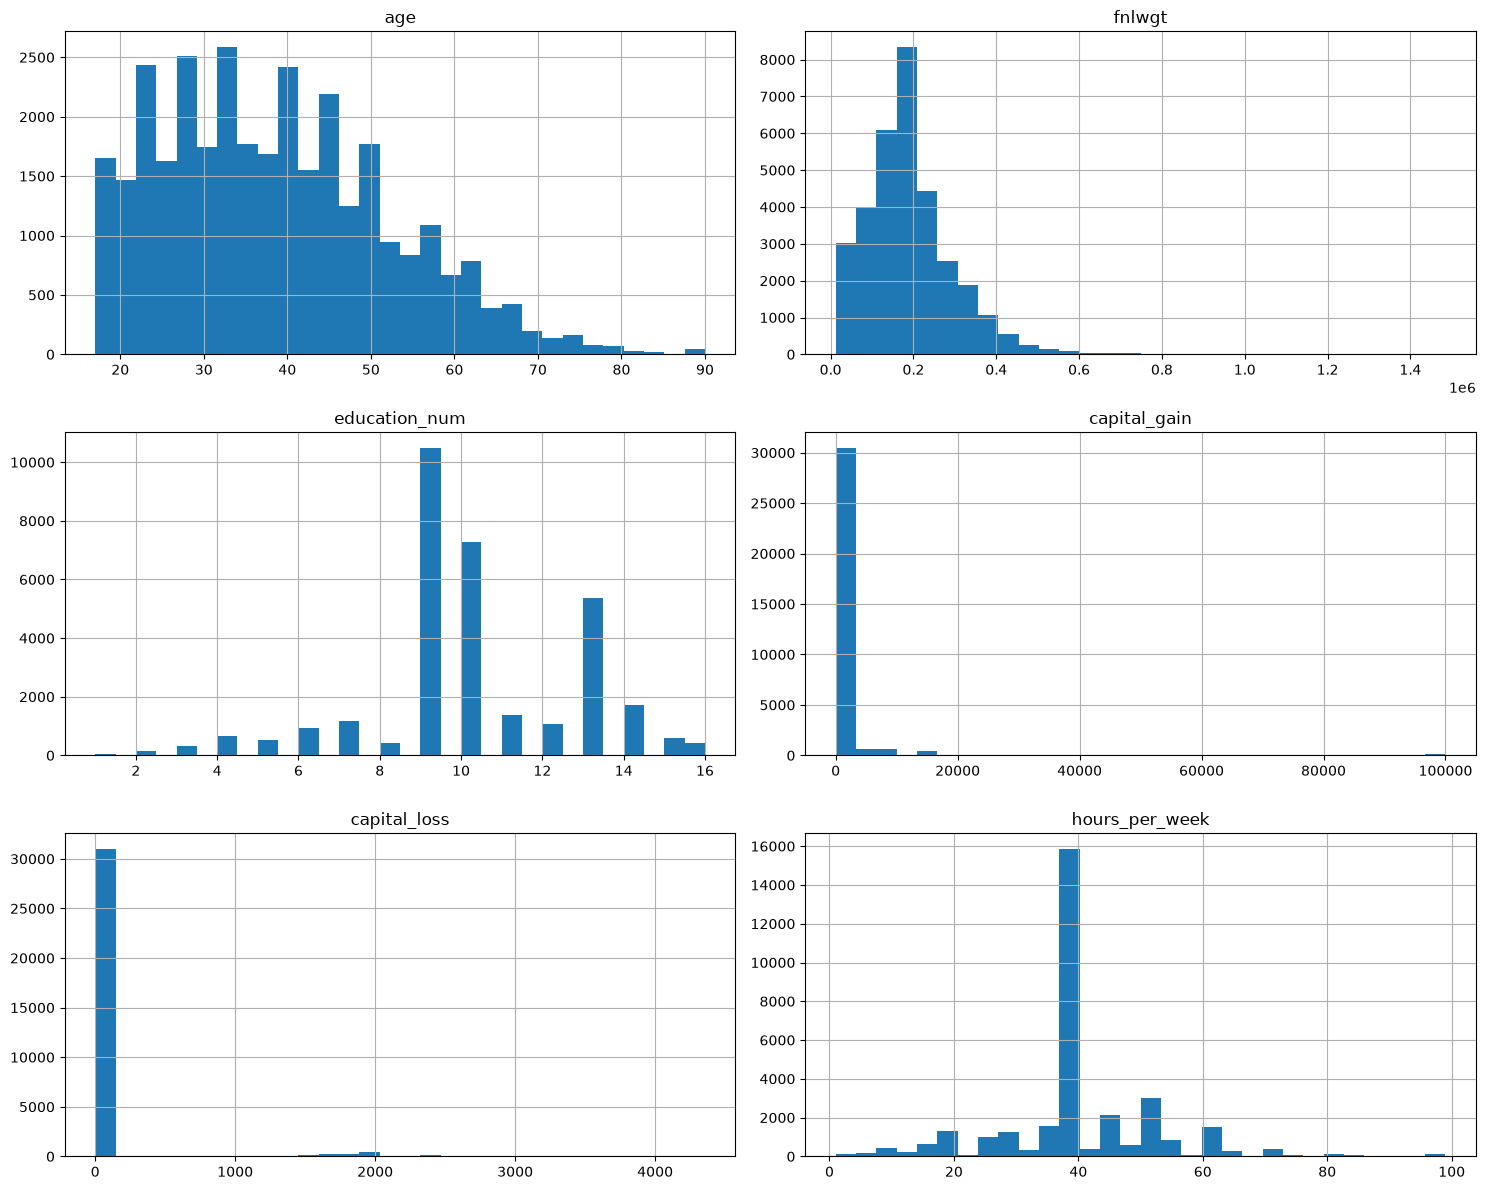

In [21]:
df[numeric_columns].hist(
    figsize=(15, 12),
    bins=30
)

plt.tight_layout()
plt.show()

Detect outliers using box plots

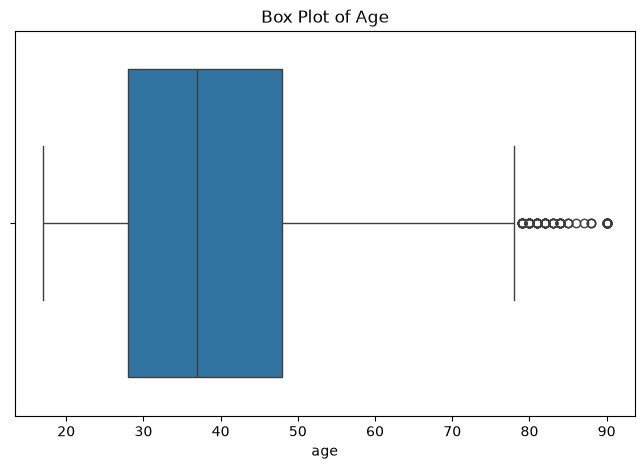

In [22]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["age"]
)

plt.title("Box Plot of Age")
plt.show()

Calculate IQR for outlier detection

In [23]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound

In [24]:
outliers_age, lower, upper = detect_outliers_iqr(df, "age")

print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of age outliers:", len(outliers_age))

Lower bound: -2.0
Upper bound: 78.0
Number of age outliers: 142


Feature engineering

In [25]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 40, 60, 100],
    labels=[
        "Young",
        "Adult",
        "Middle_Aged",
        "Senior"
    ]
)

print(df[["age", "age_group"]].head(10))

   age    age_group
0   39        Adult
1   50  Middle_Aged
2   38        Adult
3   53  Middle_Aged
4   28        Adult
5   37        Adult
6   49  Middle_Aged
7   52  Middle_Aged
8   31        Adult
9   42  Middle_Aged


Create a working-hours category

In [26]:
df["work_hours_category"] = pd.cut(
    df["hours_per_week"],
    bins=[0, 30, 40, 60, 100],
    labels=[
        "Part_Time",
        "Full_Time",
        "Over_Time",
        "Extreme"
    ]
)

print(
    df[
        ["hours_per_week", "work_hours_category"]
    ].head(10)
)

   hours_per_week work_hours_category
0              40           Full_Time
1              13           Part_Time
2              40           Full_Time
3              40           Full_Time
4              40           Full_Time
5              40           Full_Time
6              16           Part_Time
7              45           Over_Time
8              50           Over_Time
9              40           Full_Time


Create a capital-gain indicator

In [27]:
df["has_capital_gain"] = (
    df["capital_gain"] > 0
).astype(int)

print(
    df[
        ["capital_gain", "has_capital_gain"]
    ].head(10)
)

   capital_gain  has_capital_gain
0          2174                 1
1             0                 0
2             0                 0
3             0                 0
4             0                 0
5             0                 0
6             0                 0
7             0                 0
8         14084                 1
9          5178                 1


Create a capital-loss indicator

In [28]:
df["has_capital_loss"] = (
    df["capital_loss"] > 0
).astype(int)

Check the new features

In [29]:
print(
    df[
        [
            "age",
            "age_group",
            "hours_per_week",
            "work_hours_category",
            "capital_gain",
            "has_capital_gain",
            "capital_loss",
            "has_capital_loss"
        ]
    ].head(10)
)

   age    age_group  hours_per_week work_hours_category  capital_gain  \
0   39        Adult              40           Full_Time          2174   
1   50  Middle_Aged              13           Part_Time             0   
2   38        Adult              40           Full_Time             0   
3   53  Middle_Aged              40           Full_Time             0   
4   28        Adult              40           Full_Time             0   
5   37        Adult              40           Full_Time             0   
6   49  Middle_Aged              16           Part_Time             0   
7   52  Middle_Aged              45           Over_Time             0   
8   31        Adult              50           Over_Time         14084   
9   42  Middle_Aged              40           Full_Time          5178   

   has_capital_gain  capital_loss  has_capital_loss  
0                 1             0                 0  
1                 0             0                 0  
2                 0             0 

Separate features and target

In [31]:
X = df.drop("income", axis=1)

y = df["income"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (32537, 18)
Target shape: (32537,)


Split training and testing data

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (26029, 18)
Testing data: (6508, 18)


Identify numerical and categorical columns

In [33]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week', 'has_capital_gain', 'has_capital_loss']

Categorical features:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'age_group', 'work_hours_category']


Build numerical preprocessing pipeline

In [34]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

Build categorical preprocessing pipeline

In [ ]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

In [38]:
OneHotEncoder(
    handle_unknown="ignore",
    
)

,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequen

Combine preprocessing steps

In [39]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

Apply preprocessing

In [40]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

Check processed data

In [41]:
print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Processed training shape: (26029, 115)
Processed testing shape: (6508, 115)


Test StandardScaler

In [42]:
sample_data = df[
    ["age", "hours_per_week"]
].dropna()

scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    sample_data
)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=["age_scaled", "hours_scaled"]
)

print(scaled_df.head())

   age_scaled  hours_scaled
0    0.030390     -0.035664
1    0.836973     -2.222483
2   -0.042936     -0.035664
3    1.056950     -0.035664
4   -0.776193     -0.035664


Test Min-Max normalization

In [43]:
minmax_scaler = MinMaxScaler()

normalized_data = minmax_scaler.fit_transform(
    sample_data
)

normalized_df = pd.DataFrame(
    normalized_data,
    columns=["age_normalized", "hours_normalized"]
)

print(normalized_df.head())

   age_normalized  hours_normalized
0        0.301370          0.397959
1        0.452055          0.122449
2        0.287671          0.397959
3        0.493151          0.397959
4        0.150685          0.397959


Test RobustScaler

In [44]:
robust_scaler = RobustScaler()

robust_data = robust_scaler.fit_transform(
    sample_data
)

robust_df = pd.DataFrame(
    robust_data,
    columns=["age_robust", "hours_robust"]
)

print(robust_df.head())

   age_robust  hours_robust
0        0.10           0.0
1        0.65          -5.4
2        0.05           0.0
3        0.80           0.0
4       -0.45           0.0


Correlation analysis

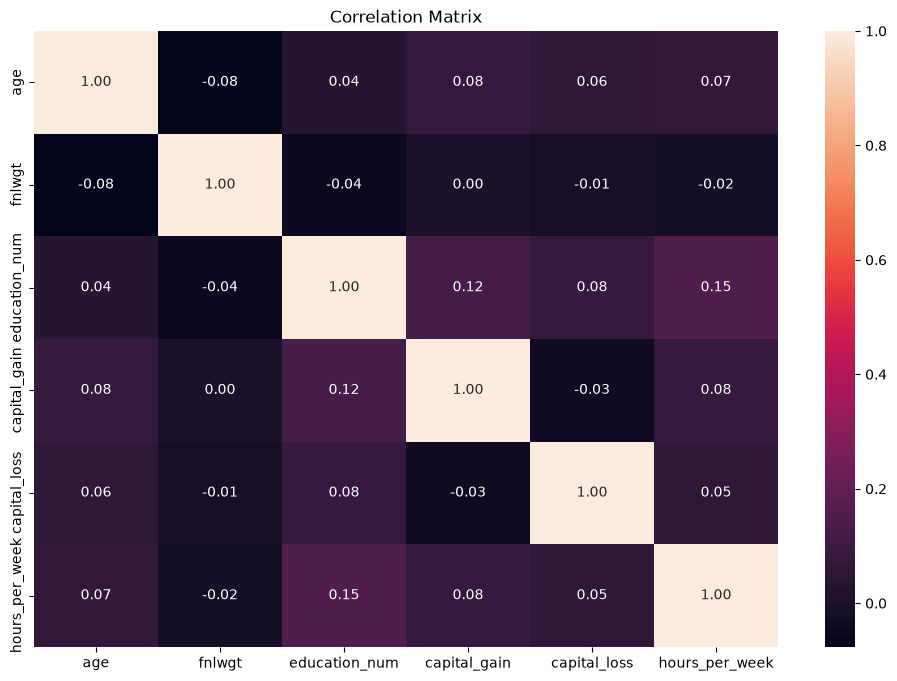

In [45]:
plt.figure(figsize=(12, 8))

correlation = df[numeric_columns].corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

Variance-based feature selection

In [46]:
variance_selector = VarianceThreshold(
    threshold=0.01
)

X_variance = variance_selector.fit_transform(
    X_train_processed
)

print(
    "Original features:",
    X_train_processed.shape[1]
)

print(
    "Features after variance selection:",
    X_variance.shape[1]
)

Original features: 115
Features after variance selection: 67


Mutual information feature selection

In [47]:
y_train_encoded = (
    y_train == ">50K"
).astype(int)

In [48]:
selector = SelectKBest(
    score_func=mutual_info_classif,
    k=10
)

X_selected = selector.fit_transform(
    X_train_processed,
    y_train_encoded
)

print(
    "Original number of features:",
    X_train_processed.shape[1]
)

print(
    "Selected number of features:",
    X_selected.shape[1]
)

Original number of features: 115
Selected number of features: 10


Final preprocessing pipeline

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessing_pipeline = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

X_train_final = preprocessing_pipeline.fit_transform(
    X_train
)

X_test_final = preprocessing_pipeline.transform(
    X_test
)

print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

Final training shape: (26029, 115)
Final testing shape: (6508, 115)


Verify there are no missing values after preprocessing

In [54]:
print(
    "Missing values in processed training data:",
    np.isnan(X_train_final).sum()
)

print(
    "Missing values in processed testing data:",
    np.isnan(X_test_final).sum()
)

Missing values in processed training data: 0
Missing values in processed testing data: 0


Verify scaling

In [55]:
print(
    "Minimum value:",
    X_train_final.min()
)

print(
    "Maximum value:",
    X_train_final.max()
)

Minimum value: -3.540741422838922
Maximum value: 13.546386419954711


Save the cleaned dataset

In [56]:
df.to_csv(
    "adult_income_engineered.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.
